In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, RocCurveDisplay,
                              ConfusionMatrixDisplay)

sns.set_theme(style="whitegrid")

In [2]:
RANDOM_SEED = 42
N_SAMPLES = 5000
rng = np.random.default_rng(RANDOM_SEED)

age = rng.integers(18, 70, N_SAMPLES)
annual_income = np.round(rng.gamma(6, 8000, N_SAMPLES) + 12000, 2)
employment_years = np.round(np.clip(rng.normal(age - 22, 5, N_SAMPLES), 0, None), 1)
num_credit_lines = rng.integers(0, 12, N_SAMPLES)
num_late_payments_2yr = np.clip(rng.poisson(1.2, N_SAMPLES), 0, 15)
existing_debt = np.round(np.clip(rng.normal(annual_income * 0.35, 6000, N_SAMPLES), 0, None), 2)
debt_to_income = np.round(existing_debt / (annual_income + 1), 3)
loan_amount = np.round(rng.gamma(2, 4000, N_SAMPLES) + 1000, 2)
loan_term_months = rng.choice([12, 24, 36, 48, 60], N_SAMPLES)
credit_history_years = np.round(np.clip(rng.normal(age - 20, 6, N_SAMPLES), 0, None), 1)
checking_balance = np.round(rng.normal(2500, 3000, N_SAMPLES), 2)
savings_balance = np.round(np.clip(rng.normal(4000, 5000, N_SAMPLES), 0, None), 2)
home_ownership = rng.choice(["own", "rent", "mortgage"], N_SAMPLES, p=[0.3, 0.35, 0.35])
purpose = rng.choice(["debt_consolidation", "car", "education", "home_improvement", "business", "medical"], N_SAMPLES)

risk_score = (-0.00002*annual_income + 0.55*debt_to_income + 0.30*num_late_payments_2yr
              - 0.05*employment_years - 0.03*credit_history_years - 0.0001*savings_balance
              - 0.00005*checking_balance + 0.00004*loan_amount + 0.01*(loan_term_months/12)
              + rng.normal(0, 0.4, N_SAMPLES))
prob_default = 1 / (1 + np.exp(-(risk_score - np.median(risk_score))))
default = (rng.random(N_SAMPLES) < prob_default).astype(int)

df = pd.DataFrame({
    "age": age, "annual_income": annual_income, "employment_years": employment_years,
    "num_credit_lines": num_credit_lines, "num_late_payments_2yr": num_late_payments_2yr,
    "existing_debt": existing_debt, "debt_to_income": debt_to_income,
    "loan_amount": loan_amount, "loan_term_months": loan_term_months,
    "credit_history_years": credit_history_years, "checking_balance": checking_balance,
    "savings_balance": savings_balance, "home_ownership": home_ownership,
    "purpose": purpose, "default": default
})

# thoda missing data add karein (real-world jaisa)
for col in ["employment_years", "savings_balance", "checking_balance"]:
    mask = rng.random(N_SAMPLES) < 0.02
    df.loc[mask, col] = np.nan

print(df.shape)
df.head()

(5000, 15)


,age,annual_income,employment_years,num_credit_lines,num_late_payments_2yr,existing_debt,debt_to_income,loan_amount,loan_term_months,credit_history_years,checking_balance,savings_balance,home_ownership,purpose,default
0,22,50541.47,3.7,1,1,21231.76,0.420,13935.25,12,0.0,2194.48,6048.95,mortgage,medical,1
1,58,73610.79,29.0,2,0,31315.95,0.425,9432.44,60,30.0,3907.58,4721.10,own,education,0
2,52,47887.68,25.4,8,0,22346.09,0.467,16914.15,60,33.6,4277.05,0.00,rent,medical,1
3,40,68439.11,20.7,9,1,23541.80,0.344,8107.06,12,18.8,1786.28,NaN,own,car,1
4,40,49956.03,NaN,8,3,16456.39,0.329,5687.65,12,18.1,2606.21,2012.21,own,medical,1


In [5]:
X = df.drop(columns=["default"])
y = df["default"]

categorical_features = X.select_dtypes(include=["object"]).columns.tolist()
numeric_features = [c for c in X.columns if c not in categorical_features]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])
preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

X_train_t = preprocessor.fit_transform(X_train)
X_test_t = preprocessor.transform(X_test)

print("Train shape:", X_train_t.shape, "| Test shape:", X_test_t.shape)

Train shape: (4000, 21) | Test shape: (1000, 21)


In [6]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42),
    "Decision Tree": DecisionTreeClassifier(max_depth=6, class_weight="balanced", random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=300, max_depth=10, class_weight="balanced", random_state=42, n_jobs=-1)
}

for name, model in models.items():
    model.fit(X_train_t, y_train)
    print(f"Trained: {name}")

Trained: Logistic Regression
Trained: Decision Tree
Trained: Random Forest


In [7]:
rows = []
for name, model in models.items():
    y_pred = model.predict(X_test_t)
    y_proba = model.predict_proba(X_test_t)[:, 1]
    rows.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba)
    })

results = pd.DataFrame(rows).sort_values("ROC-AUC", ascending=False)
results

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.728,0.721344,0.735887,0.728543,0.805800
2,Random Forest,0.731,0.726547,0.733871,0.730191,0.792171
1,Decision Tree,0.682,0.671815,0.701613,0.686391,0.746944


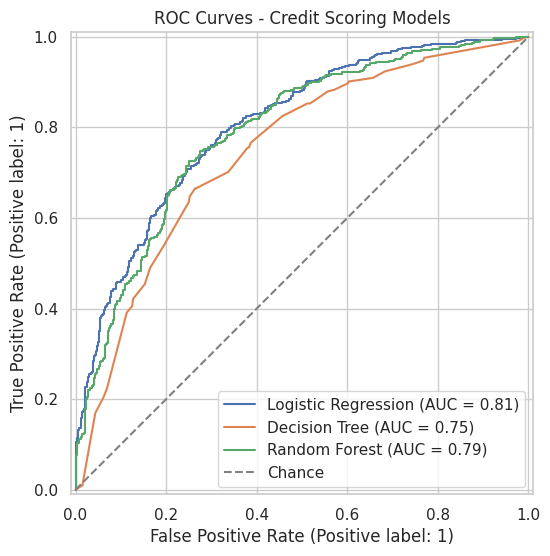

In [8]:
fig, ax = plt.subplots(figsize=(7,6))
for name, model in models.items():
    RocCurveDisplay.from_estimator(model, X_test_t, y_test, name=name, ax=ax)
ax.plot([0,1],[0,1], linestyle="--", color="gray", label="Chance")
ax.set_title("ROC Curves - Credit Scoring Models")
ax.legend()
plt.show()

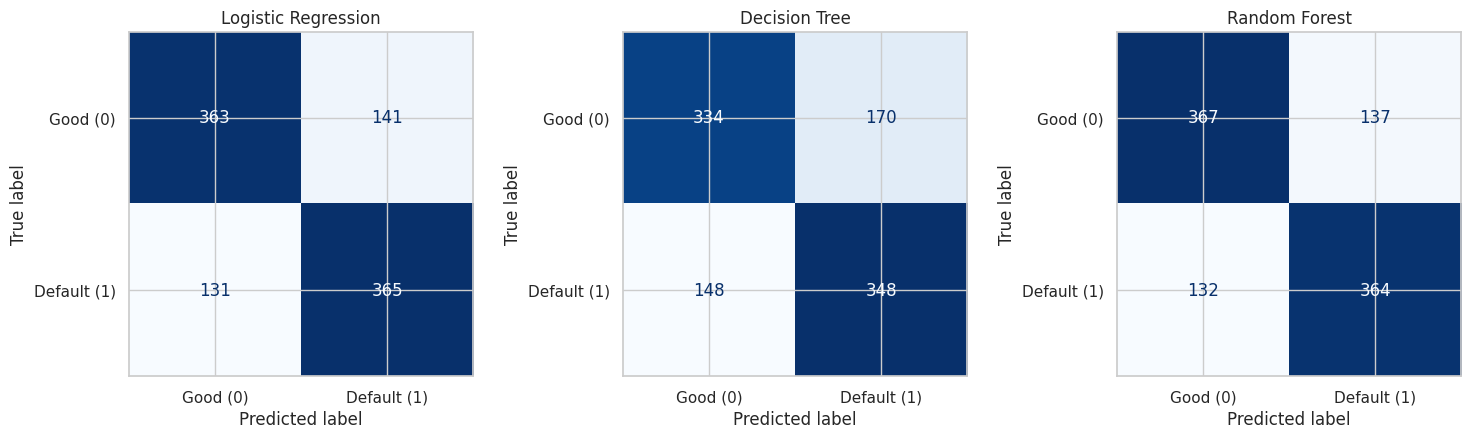

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, (name, model) in zip(axes, models.items()):
    y_pred = model.predict(X_test_t)
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax, cmap="Blues",
                                             display_labels=["Good (0)", "Default (1)"], colorbar=False)
    ax.set_title(name)
plt.tight_layout()
plt.show()